,Velocity,Angle,Gravity,AirResistance,Range
0,43.708611,26.107976,9.761706,0.201811,130.101463
1,95.564288,47.514057,9.746979,0.239004,711.844794
2,75.879455,67.376750,10.406255,0.075140,360.359349
3,63.879264,58.933493,9.749546,0.187462,302.920701
4,24.041678,63.393669,9.771950,0.171524,36.949788


,Model,MAE,RMSE,R2
2,Random Forest,14.797037,21.669909,0.990546
1,Decision Tree,23.716910,37.385058,0.971862
3,KNN,24.846524,37.564502,0.971592
0,Linear Regression,59.889351,79.606008,0.872420
4,SVR,81.499612,130.674086,0.656229


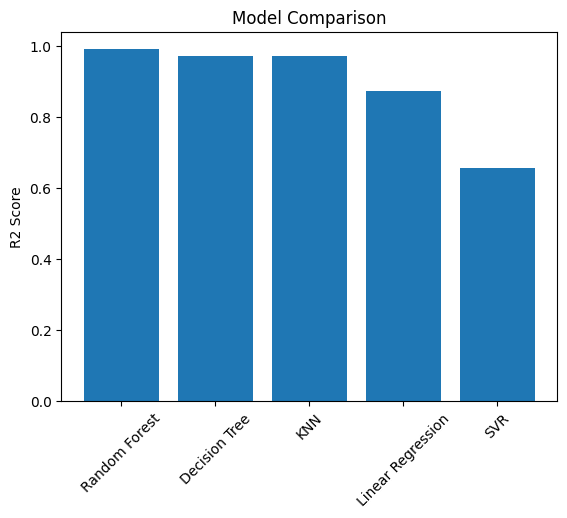

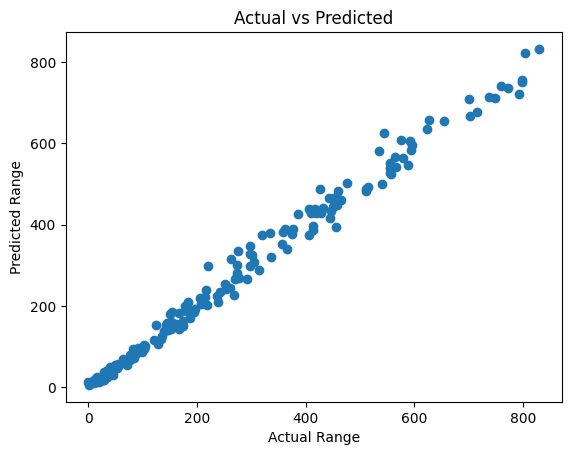

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

n = 1000

velocity = np.random.uniform(10, 100, n)
angle = np.random.uniform(15, 75, n)
gravity = np.random.uniform(9.5, 10.5, n)
air = np.random.uniform(0.0, 0.3, n)

angle_rad = np.deg2rad(angle)

range_val = (velocity**2 * np.sin(2 * angle_rad)) / gravity
range_val = range_val * (1 - air)
range_val = range_val + np.random.normal(0, 5, n)

data = pd.DataFrame({
    "Velocity": velocity,
    "Angle": angle,
    "Gravity": gravity,
    "AirResistance": air,
    "Range": range_val
})

display(data.head())

X = data.drop("Range", axis=1)
y = data["Range"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append([name, mae, rmse, r2])

result_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
result_df = result_df.sort_values("R2", ascending=False)

display(result_df)

plt.figure()
plt.bar(result_df["Model"], result_df["R2"])
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

best_model_name = result_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, best_pred)
plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Actual vs Predicted")
plt.show()